# 동물상 분류 모델 데이터
- 최소 데이터: 20개 클래스, 50장씩


## 1. 데이터 준비

### 1) 데이터 수집

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import time

In [ ]:
from bing_image_downloader import downloader

downloader.download(
    query="알파카상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="공룡상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="원숭이상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="오리상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="코알라상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="늑대상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="햄스터상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="꽃돼지상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="너구리상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

downloader.download(
    query="말상",             # 검색어
    limit=50,
    output_dir="./dataset/raw",     # 파일 저장 위치
    adult_filter_off=True,
    force_replace=False,
    timeout=30 
)

### 2) 얼굴 추출
- 1) dataset/raw/<클래스>/(클래스당 70장)에서 이미지를 읽어 얼굴을 검출하고, 검출되면 랜드마크 기반으로 112×112 정렬 크롭(norm_crop)을 생성
    - 얼굴 검출/정렬이 실패한 이미지는 중앙 크롭 후 112×112로 리사이즈하여 대체
- 2) 검출 점수(det_score)와 정렬 성공 여부를 기반으로 점수를 매겨 클래스당 상위 50장을 dataset/selected50/<클래스>/에 저장

In [ ]:
import cv2, numpy as np, random
from pathlib import Path
from insightface.app import FaceAnalysis
from insightface.utils.face_align import norm_crop

# 유니코드 경로 읽기/쓰기 
def imread_unicode(path: Path):
    data = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

def imwrite_unicode_jpg(path: Path, img):
    path.parent.mkdir(parents=True, exist_ok=True)
    ok, buf = cv2.imencode(".jpg", img)
    if not ok:
        raise RuntimeError(f"imencode failed: {path}")
    buf.tofile(str(path))

def center_square_resize(img, size=112):
    h, w = img.shape[:2]
    s = min(h, w)
    y1 = (h - s) // 2
    x1 = (w - s) // 2
    crop = img[y1:y1+s, x1:x1+s]
    return cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# 설정
RAW_DIR = Path("dataset/raw")             # 클래스당 70장
SELECTED_DIR = Path("dataset/selected50") # 클래스당 50장 저장
TARGET_PER_CLASS = 50
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# 검출률 높이기
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(1280, 1280), det_thresh=0.1)

def detect_best_face(app, img):
    # 1) 원본
    faces = app.get(img)
    if faces:
        face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]))
        return face, img

    # 2) padding
    h, w = img.shape[:2]
    pad = int(0.25 * max(h, w))
    img_pad = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=(0, 0, 0))
    faces = app.get(img_pad)
    if faces:
        face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]))
        return face, img_pad

    # 3) upsample
    scale = 1.5
    img_up = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_CUBIC)
    faces = app.get(img_up)
    if faces:
        face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]))
        return face, img_up

    return None, img

# raw(70) -> selected50(50)
SELECTED_DIR.mkdir(parents=True, exist_ok=True)

for cls_dir in [d for d in RAW_DIR.iterdir() if d.is_dir()]:
    imgs = [p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
    if not imgs:
        print(f"[WARN] no images: {cls_dir.name}")
        continue

    random.shuffle(imgs)

    candidates = []  # (score, cropped112, src_path)
    for p in imgs:
        img = imread_unicode(p)
        if img is None:
            continue

        face, used_img = detect_best_face(app, img)

        if face is not None and getattr(face, "kps", None) is not None:
            out = norm_crop(used_img, face.kps)  # 112x112
            det_score = float(getattr(face, "det_score", 0.0))
            score = det_score + 1.0  # aligned 보너스
        else:
            out = center_square_resize(img, 112)
            score = 0.0  # fallback는 낮게

        candidates.append((score, out, p))

    if len(candidates) < TARGET_PER_CLASS:
        print(f"[WARN] {cls_dir.name}: candidates={len(candidates)} < target={TARGET_PER_CLASS} (그래도 진행)")

    candidates.sort(key=lambda x: x[0], reverse=True)
    selected = candidates[:TARGET_PER_CLASS]

    out_cls = SELECTED_DIR / cls_dir.name
    out_cls.mkdir(parents=True, exist_ok=True)

    for i, (score, out_img, src) in enumerate(selected, start=1):
        out_name = f"{cls_dir.name}_{i:03d}.jpg"
        imwrite_unicode_jpg(out_cls / out_name, out_img)

    print(f"selected50 {cls_dir.name}: selected={len(selected)} (top_score={selected[0][0] if selected else None})")

print("\nStep1 done:", SELECTED_DIR.resolve())

### 3) train / test 분리
- 1) dataset/selected50/<클래스>/의 이미지를 클래스별로 셔플한 뒤 80/20(train/test)로 분리
- 2) dataset/train/<클래스>/, dataset/test/<클래스>/에 복사

In [1]:
import random, shutil
from pathlib import Path

# 설정
SELECTED_DIR = Path("dataset/selected50")
TRAIN_DIR    = Path("dataset/train")
TEST_DIR     = Path("dataset/test")

TRAIN_RATIO = 0.8
SEED = 42
COPY_MODE = True         # True=복사, False=이동
CLEAR_OUTPUT = True      # train/test 폴더를 비우고 다시 생성

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

random.seed(SEED)

def copy_or_move(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if COPY_MODE:
        shutil.copy2(src, dst)   # 동일 파일명 있으면 덮어씀
    else:
        shutil.move(str(src), str(dst))

def clear_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def split_train_test(paths, train_ratio=0.8):
    paths = list(paths)
    random.shuffle(paths)
    n = len(paths)
    n_train = int(n * train_ratio)
    if n >= 2:
        n_train = min(max(n_train, 1), n - 1)  # 최소 1장씩은 배정
    return paths[:n_train], paths[n_train:]

# 실행
if not SELECTED_DIR.exists():
    raise FileNotFoundError(f"Not found: {SELECTED_DIR.resolve()}")

if CLEAR_OUTPUT:
    clear_dir(TRAIN_DIR)
    clear_dir(TEST_DIR)

for cls_dir in [d for d in SELECTED_DIR.iterdir() if d.is_dir()]:
    imgs = [p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
    if not imgs:
        print(f"[WARN] no images: {cls_dir.name}")
        continue

    train_list, test_list = split_train_test(imgs, TRAIN_RATIO)

    for src in train_list:
        copy_or_move(src, TRAIN_DIR / cls_dir.name / src.name)

    for src in test_list:
        copy_or_move(src, TEST_DIR / cls_dir.name / src.name)

    print(f"split {cls_dir.name}: total={len(imgs)}, train={len(train_list)}, test={len(test_list)}")

print("\nDone!")
print("Train:", TRAIN_DIR.resolve())
print("Test :", TEST_DIR.resolve())

split 공룡상: total=50, train=40, test=10
split 꽃돼지상: total=50, train=40, test=10
split 너구리상: total=50, train=40, test=10
split 늑대상: total=50, train=40, test=10
split 말상: total=50, train=40, test=10
split 알파카상: total=50, train=40, test=10
split 오리상: total=50, train=40, test=10
split 원숭이상: total=50, train=40, test=10
split 코알라상: total=50, train=40, test=10
split 햄스터상: total=50, train=40, test=10

Done!
Train: C:\workspace\project2\gachikium\유현희\dataset\train
Test : C:\workspace\project2\gachikium\유현희\dataset\test


### 4) ArcFace 임베딩

In [3]:
import cv2, numpy as np
from pathlib import Path
from insightface.app import FaceAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
TRAIN_DIR = Path("dataset/train")
TEST_DIR  = Path("dataset/test")

# 1) buffalo_l 로드
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))   # GPU면 0, CPU면 -1

# 2) ArcFace 임베딩 모델 꺼내기
rec = app.models.get("recognition")
if rec is None:
    raise RuntimeError(f"recognition model not found. keys={list(app.models.keys())}")

# 유니코드 경로 읽기
def imread_unicode(path: Path):
    data = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

# L2 정규화
def l2_normalize(x):
    return x / (np.linalg.norm(x) + 1e-12)

# 112x112 얼굴 이미지 -> 512차원 임베딩
def get_embedding_112_bgr(img_bgr_112):
    if hasattr(rec, "get_feat"):
        emb = rec.get_feat(img_bgr_112)
    else:
        raise RuntimeError(f"rec has no get_feat(). available: {dir(rec)}")

    emb = np.asarray(emb).reshape(-1)
    return l2_normalize(emb).astype(np.float32)

# train/test 폴더 이미지를 임베딩으로 변환
# 학습 데이터는 기존 방식 유지: 이미 얼굴 추출된 이미지라고 보고 112x112로만 맞춤
def load_split_embeddings(root_dir: Path):
    X, y = [], []
    classes = sorted([d.name for d in root_dir.iterdir() if d.is_dir()])
    class_to_idx = {c: i for i, c in enumerate(classes)}

    for cls in classes:
        cls_dir = root_dir / cls
        files = sorted(
            [p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS],
            key=lambda p: p.name
        )

        for p in files:
            img = imread_unicode(p)
            if img is None:
                continue

            if img.shape[0] != 112 or img.shape[1] != 112:
                img = cv2.resize(img, (112, 112), interpolation=cv2.INTER_AREA)

            X.append(get_embedding_112_bgr(img))
            y.append(class_to_idx[cls])

    return np.vstack(X), np.array(y), classes

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\user/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']

## 2. 분류기 학습/평가

### 1) 평가 함수

In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate(clf, X_test, y_test, classes):
    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("Test Accuracy:", acc)

    print("\n[Classification Report]")
    print(classification_report(y_test, pred, target_names=classes))

    print("\n[Confusion Matrix]")
    print(confusion_matrix(y_test, pred))

### 2) LogisticRegression

In [5]:
# 데이터 준비
X_train, y_train, classes = load_split_embeddings(TRAIN_DIR)
X_test,  y_test,  _       = load_split_embeddings(TEST_DIR)

print("X_train:", X_train.shape, "X_test:", X_test.shape, "num_classes:", len(classes))

def train_logistic(X_train, y_train):
    clf = LogisticRegression(max_iter=5000)
    clf.fit(X_train, y_train)
    return clf

log_clf = train_logistic(X_train, y_train)

print("[LogisticRegression 결과]")
evaluate(log_clf, X_test, y_test, classes)

X_train: (400, 512) X_test: (100, 512) num_classes: 10
[LogisticRegression 결과]
Test Accuracy: 0.85

[Classification Report]
              precision    recall  f1-score   support

         공룡상       0.80      0.80      0.80        10
        꽃돼지상       1.00      0.70      0.82        10
        너구리상       0.90      0.90      0.90        10
         늑대상       0.77      1.00      0.87        10
          말상       1.00      0.80      0.89        10
        알파카상       0.75      0.90      0.82        10
         오리상       0.75      0.90      0.82        10
        원숭이상       0.82      0.90      0.86        10
        코알라상       1.00      0.60      0.75        10
        햄스터상       0.91      1.00      0.95        10

    accuracy                           0.85       100
   macro avg       0.87      0.85      0.85       100
weighted avg       0.87      0.85      0.85       100


[Confusion Matrix]
[[ 8  0  1  1  0  0  0  0  0  0]
 [ 0  7  0  0  0  0  2  0  0  1]
 [ 1  0  9  0  0  0  0  0  0  0

### 3) LinearSVC

In [6]:
def train_linear_svm(X_train, y_train):
    clf = LinearSVC()
    clf.fit(X_train, y_train)
    return clf

svm_clf = train_linear_svm(X_train, y_train)

print("[LinearSVC 결과]")
evaluate(svm_clf, X_test, y_test, classes)

[LinearSVC 결과]
Test Accuracy: 0.89

[Classification Report]
              precision    recall  f1-score   support

         공룡상       0.82      0.90      0.86        10
        꽃돼지상       1.00      1.00      1.00        10
        너구리상       1.00      0.90      0.95        10
         늑대상       0.83      1.00      0.91        10
          말상       1.00      0.90      0.95        10
        알파카상       0.82      0.90      0.86        10
         오리상       0.75      0.90      0.82        10
        원숭이상       0.89      0.80      0.84        10
        코알라상       1.00      0.70      0.82        10
        햄스터상       0.90      0.90      0.90        10

    accuracy                           0.89       100
   macro avg       0.90      0.89      0.89       100
weighted avg       0.90      0.89      0.89       100


[Confusion Matrix]
[[ 9  0  0  1  0  0  0  0  0  0]
 [ 0 10  0  0  0  0  0  0  0  0]
 [ 1  0  9  0  0  0  0  0  0  0]
 [ 0  0  0 10  0  0  0  0  0  0]
 [ 0  0  0  0  9  1  0  0  0 

## 3. 하이퍼파라미터 튜닝

### 1) ArcFace 임베딩 기반 Logistic Regression / LinearSVC 최적화

In [7]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

X = X_train
y = y_train

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    model_type = trial.suggest_categorical("model", ["logreg", "linearsvc"])
    C = trial.suggest_float("C", 1e-3, 1e3, log=True)
    use_pca = trial.suggest_categorical("use_pca", [False, True])

    n_splits = cv.get_n_splits()
    n_train_fold_min = int(np.floor(X.shape[0] * (n_splits - 1) / n_splits))
    max_pca = min(X.shape[1], n_train_fold_min - 1)
    max_pca = (max_pca // 64) * 64

    steps = [("scaler", StandardScaler())]

    if use_pca and max_pca >= 64:
        n_components = trial.suggest_int("pca_dim", 64, max_pca, step=64)
        steps.append((
            "pca",
            PCA(
                n_components=n_components,
                random_state=42,
                svd_solver="randomized"
            )
        ))
    else:
        steps.append(("pca", "passthrough"))

    if model_type == "logreg":
        clf = LogisticRegression(
            C=C,
            max_iter=5000,
            class_weight="balanced"
        )
    else:
        clf = LinearSVC(
            C=C,
            class_weight="balanced",
            max_iter=5000
        )

    steps.append(("clf", clf))
    pipe = Pipeline(steps)

    return cross_val_score(pipe, X, y, cv=cv, scoring="accuracy").mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best score:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-10 09:34:53,912] A new study created in memory with name: no-name-e2070582-af5a-431e-bd38-9436757de426
[I 2026-03-10 09:34:54,593] Trial 0 finished with value: 0.875 and parameters: {'model': 'logreg', 'C': 0.033816352146289565, 'use_pca': True, 'pca_dim': 192}. Best is trial 0 with value: 0.875.
[I 2026-03-10 09:34:55,439] Trial 1 finished with value: 0.86 and parameters: {'model': 'linearsvc', 'C': 0.001610304962349503, 'use_pca': True, 'pca_dim': 192}. Best is trial 0 with value: 0.875.
[I 2026-03-10 09:35:05,706] Trial 2 finished with value: 0.8700000000000001 and parameters: {'model': 'linearsvc', 'C': 1.3730114982897534, 'use_pca': True, 'pca_dim': 256}. Best is trial 0 with value: 0.875.
c:\workspace\project2\gachikium\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\workspace\project2\gachikium\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarnin

Best score: 0.8825
Best params: {'model': 'logreg', 'C': 151.84598679558133, 'use_pca': False}


- Best score: 0.8825
    - Optuna가 여러 설정으로 50번(네 설정 기준) 실험해본 결과, 교차검증(5-fold) 평균 정확도가 가장 높았던 조합의 점수가 0.8825(= 88.25%)였다는 의미
- Best params: {'model': 'logreg', 'C': 51.00466600532521, 'use_pca': False}
    - ArcFace 임베딩(512차)을 그대로 쓰고, Logistic Regression을 C≈51로 학습했을 때 평균 정확도가 88.25%로 가장 좋았다는 의미

## 4. 최종 모델 확정

### 1) 베스트 파라미터로 전체 train 데이터 재학습

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

best = study.best_params
print("best =", best)

steps = [("scaler", StandardScaler())]

if best["use_pca"]:
    steps.append((
        "pca",
        PCA(
            n_components=best["pca_dim"],
            random_state=42,
            svd_solver="randomized"
        )
    ))
else:
    steps.append(("pca", "passthrough"))

if best["model"] == "logreg":
    best_clf = LogisticRegression(
        C=best["C"],
        max_iter=5000,
        class_weight="balanced"
    )
else:
    best_clf = LinearSVC(
        C=best["C"],
        class_weight="balanced",
        max_iter=5000
    )

steps.append(("clf", best_clf))

final_model = Pipeline(steps)
final_model.fit(X_train, y_train)

print("final_model 학습 완료")
print("모델:", best["model"])
print("C:", best["C"])
print("PCA 사용:", best["use_pca"])
if best["use_pca"]:
    print("PCA 차원:", best["pca_dim"])

best = {'model': 'logreg', 'C': 151.84598679558133, 'use_pca': False}
final_model 학습 완료
모델: logreg
C: 151.84598679558133
PCA 사용: False


### 2) test 데이터로 최종 1회 평가

In [9]:
y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

print("\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=classes))

print("\n[Confusion Matrix]")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.91

[Classification Report]
              precision    recall  f1-score   support

         공룡상       0.77      1.00      0.87        10
        꽃돼지상       1.00      1.00      1.00        10
        너구리상       1.00      0.90      0.95        10
         늑대상       0.91      1.00      0.95        10
          말상       1.00      0.90      0.95        10
        알파카상       0.80      0.80      0.80        10
         오리상       0.90      0.90      0.90        10
        원숭이상       0.90      0.90      0.90        10
        코알라상       1.00      0.80      0.89        10
        햄스터상       0.90      0.90      0.90        10

    accuracy                           0.91       100
   macro avg       0.92      0.91      0.91       100
weighted avg       0.92      0.91      0.91       100


[Confusion Matrix]
[[10  0  0  0  0  0  0  0  0  0]
 [ 0 10  0  0  0  0  0  0  0  0]
 [ 1  0  9  0  0  0  0  0  0  0]
 [ 0  0  0 10  0  0  0  0  0  0]
 [ 0  0  0  0  9  1  0  0  0  0]
 [ 0  0  0 

### 3) Occlusion 기반 중요 영역 시각화

Predicted: 오리상


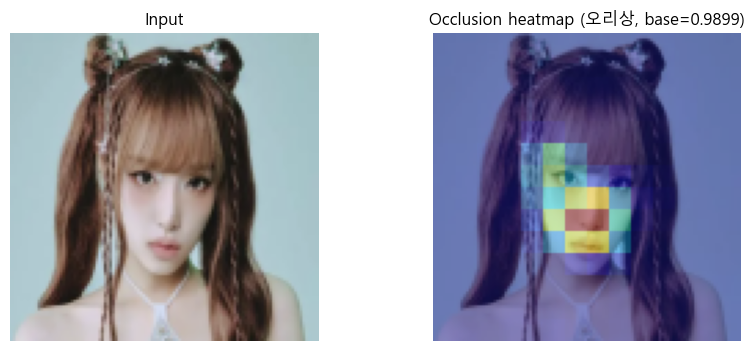

In [43]:
from pathlib import Path
import matplotlib.pyplot as plt

img_path = Path("./infer/testImg1.png")  # 필요시 변경

aligned = imread_unicode(img_path)
if aligned is None:
    raise RuntimeError(f"이미지 읽기 실패: {img_path.resolve()}")

if aligned.shape[:2] != (112, 112):
    aligned = cv2.resize(aligned, (112, 112), interpolation=cv2.INTER_AREA)

def get_class_score(model, emb_512, class_index: int):
    x = emb_512.reshape(1, -1)

    if hasattr(model, "predict_proba"):
        return float(model.predict_proba(x)[0, class_index])

    if hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function(x))
        if scores.ndim == 1:
            return float(scores[class_index] if scores.shape[0] > 1 else scores[0])
        return float(scores[0, class_index])

    pred = model.predict(x)[0]
    return float(pred == class_index)

emb0 = get_embedding_112_bgr(aligned)

if hasattr(final_model, "predict_proba"):
    probs = final_model.predict_proba(emb0.reshape(1, -1))[0]
    pred_idx = int(np.argmax(probs))
    base_score = float(probs[pred_idx])
else:
    scores = np.asarray(final_model.decision_function(emb0.reshape(1, -1)))
    if scores.ndim == 1:
        pred_idx = int(np.argmax(scores))
        base_score = float(scores[pred_idx] if scores.shape[0] > 1 else scores[0])
    else:
        pred_idx = int(np.argmax(scores[0]))
        base_score = float(scores[0, pred_idx])

pred_name = classes[pred_idx]
print("Predicted:", pred_name)

patch = 16
stride = 8
mask_value = 0

H, W = aligned.shape[:2]
heat = np.zeros((H, W), dtype=np.float32)
count = np.zeros((H, W), dtype=np.float32)

for y0 in range(0, H - patch + 1, stride):
    for x0 in range(0, W - patch + 1, stride):
        masked = aligned.copy()
        masked[y0:y0+patch, x0:x0+patch] = mask_value

        emb = get_embedding_112_bgr(masked)
        score = get_class_score(final_model, emb, pred_idx)

        drop = base_score - score
        heat[y0:y0+patch, x0:x0+patch] += drop
        count[y0:y0+patch, x0:x0+patch] += 1.0

heat = heat / np.maximum(count, 1e-6)
heat = heat - heat.min()
if heat.max() > 0:
    heat = heat / heat.max()

img_rgb = cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB)
heat_u8 = (heat * 255).astype(np.uint8)
heat_color = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)
overlay = cv2.addWeighted(img_rgb, 0.6, heat_color, 0.4, 0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Input")
plt.axis("off")
plt.imshow(img_rgb)

plt.subplot(1, 2, 2)
plt.title(f"Occlusion heatmap ({pred_name}, base={base_score:.4f})")
plt.axis("off")
plt.imshow(overlay)

plt.show()

### 4) 오답 이미지/결과 시각화

오답 개수: 9


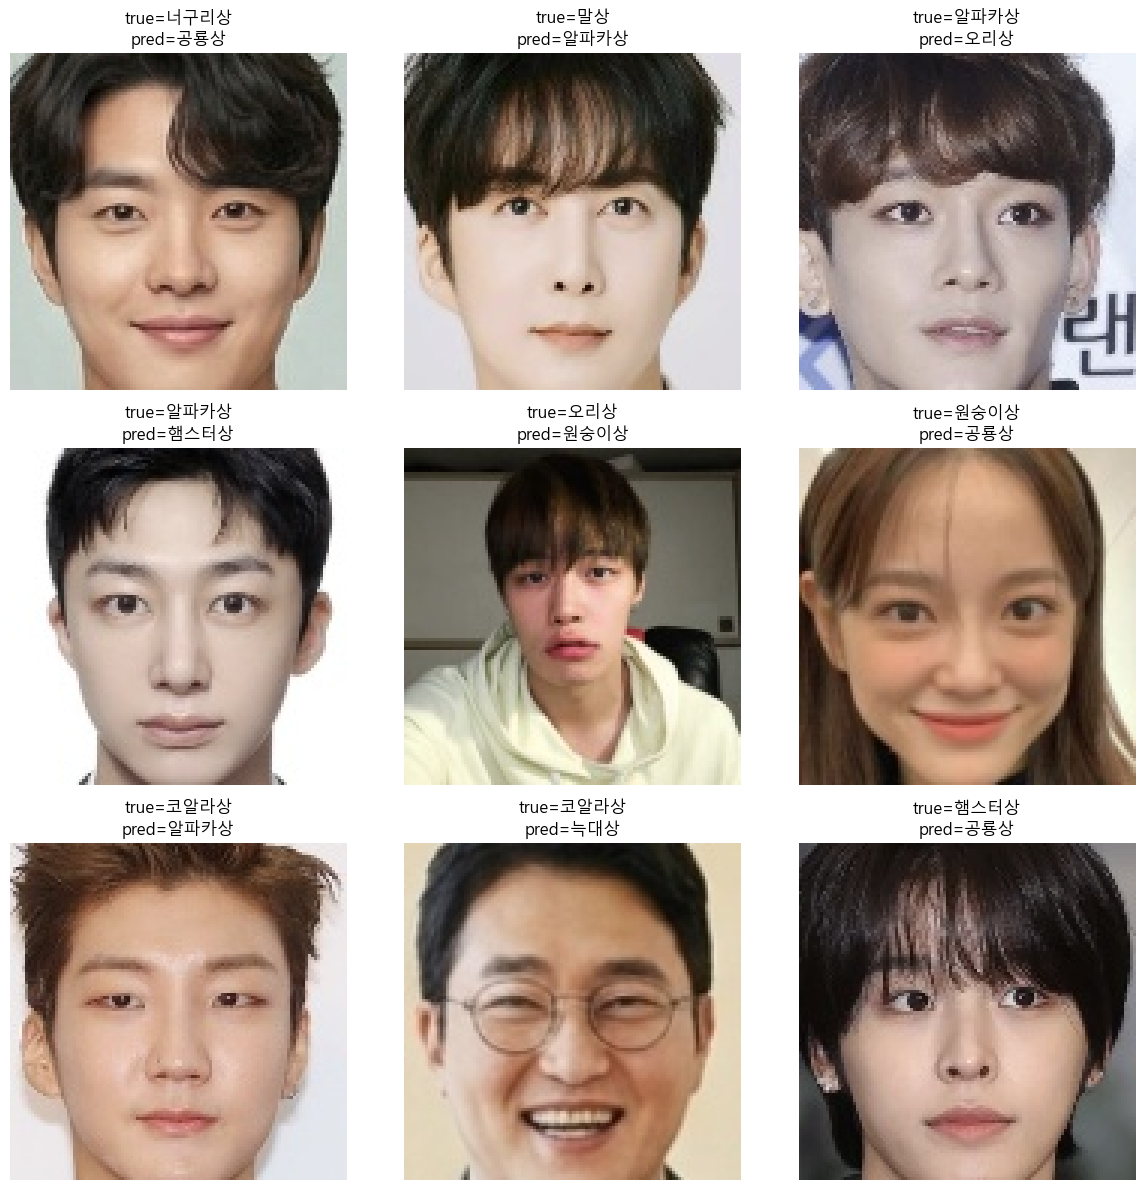

In [44]:
import matplotlib.pyplot as plt

def show_misclassified_examples(model, root_dir: Path, classes, max_show=9):
    samples = []

    for cls_idx, cls_name in enumerate(classes):
        cls_dir = root_dir / cls_name
        files = sorted([p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS])

        for p in files:
            img = imread_unicode(p)
            if img is None:
                continue

            if img.shape[:2] != (112, 112):
                img = cv2.resize(img, (112, 112), interpolation=cv2.INTER_AREA)

            emb = get_embedding_112_bgr(img).reshape(1, -1)
            pred_idx = int(model.predict(emb)[0])

            if pred_idx != cls_idx:
                samples.append((p, cls_idx, pred_idx, img))

    print("오답 개수:", len(samples))

    if not samples:
        print("오답 이미지가 없습니다.")
        return

    show_n = min(max_show, len(samples))
    cols = 3
    rows = int(np.ceil(show_n / cols))

    plt.figure(figsize=(12, 4 * rows))
    for i in range(show_n):
        p, true_idx, pred_idx, img112 = samples[i]
        img_rgb = cv2.cvtColor(img112, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(f"true={classes[true_idx]}\npred={classes[pred_idx]}")

    plt.tight_layout()
    plt.show()

show_misclassified_examples(final_model, TEST_DIR, classes, max_show=9)

## 5. 모델 저장

In [45]:
import joblib
from pathlib import Path

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {"model": final_model, "classes": classes},
    MODEL_DIR / "animal_face_final.joblib"
)

print("saved:", (MODEL_DIR / "animal_face_final.joblib").resolve())

saved: C:\workspace\project2\gachikium\유현희\model\animal_face_final.joblib


## 6. 예측

### 1) 얼굴 전처리 공통 함수

In [46]:
import cv2, numpy as np, joblib
from pathlib import Path
from insightface.app import FaceAnalysis
from insightface.utils.face_align import norm_crop

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def imread_unicode(path: Path):
    data = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

def l2_normalize(x):
    return x / (np.linalg.norm(x) + 1e-12)

bundle = joblib.load("model/animal_face_final.joblib")
pred_model = bundle["model"]
pred_classes = bundle["classes"]

pred_app = FaceAnalysis(name="buffalo_l")
pred_app.prepare(ctx_id=0, det_size=(640, 640))

pred_rec = pred_app.models.get("recognition")
if pred_rec is None:
    raise RuntimeError(f"recognition model not found. keys={list(pred_app.models.keys())}")

def face_to_112(img_bgr):
    faces = pred_app.get(img_bgr)
    if not faces:
        return None

    face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]))

    if getattr(face, "kps", None) is not None:
        return norm_crop(img_bgr, face.kps)
    else:
        x1, y1, x2, y2 = map(int, face.bbox)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = max(0, x2), max(0, y2)
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            return None
        return cv2.resize(crop, (112, 112), interpolation=cv2.INTER_AREA)

def get_pred_embedding_112_bgr(img_112):
    if hasattr(pred_rec, "get_feat"):
        emb = pred_rec.get_feat(img_112)
        emb = np.asarray(emb).reshape(-1)
    else:
        raise RuntimeError("pred_rec.get_feat not found.")
    return l2_normalize(emb).astype(np.float32)

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\user/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']

### 2) 얼굴 전처리 공통 함수 사용하여 학습 데이터 로딩
- 예측 시 얼굴 전처리 공통 함수(face_to_112, get_pred_embedding_112_bgr)를 사용

### 3) 예측할 파일 1개

In [48]:
def topk_candidates_from_model(model, emb_1x512, classes, k=3):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(emb_1x512)[0]
        idxs = np.argsort(-proba)[:k]
        return [(classes[i], float(proba[i])) for i in idxs]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(emb_1x512)
        scores = np.asarray(scores)

        if scores.ndim == 1:
            idxs = np.argsort(-scores)[:k]
            return [(classes[i], float(scores[i])) for i in idxs]
        else:
            idxs = np.argsort(-scores[0])[:k]
            return [(classes[i], float(scores[0, i])) for i in idxs]

    pred_idx = int(model.predict(emb_1x512)[0])
    return [(classes[pred_idx], 1.0)]

def predict_one(image_path: str, topk=3):
    p = Path(image_path)
    img = imread_unicode(p)
    if img is None:
        return {"path": str(p), "ok": False, "reason": "failed_to_read"}

    img112 = face_to_112(img)
    if img112 is None:
        return {"path": str(p), "ok": False, "reason": "no_face_detected"}

    emb = get_pred_embedding_112_bgr(img112)
    emb_1x = emb.reshape(1, -1)

    pred_idx = int(pred_model.predict(emb_1x)[0])
    pred_name = pred_classes[pred_idx]
    topk_list = topk_candidates_from_model(pred_model, emb_1x, pred_classes, k=topk)

    return {
        "path": str(p),
        "ok": True,
        "pred": pred_name,
        "topk": topk_list,
    }

def print_prediction_result(result):
    print("=" * 60)
    print("[예측 결과]")
    print(f"파일 경로 : {result['path']}")
    print(f"처리 성공 : {result['ok']}")

    if not result["ok"]:
        print(f"실패 이유 : {result['reason']}")
        print("=" * 60)
        return

    print(f"예측 클래스 : {result['pred']}")
    print("\n[top-3 후보]")
    for i, (name, score) in enumerate(result["topk"], start=1):
        print(f"{i}. {name:10s}  score = {score:.6f}")
    print("=" * 60)
    
result = predict_one("./infer/testImg1.png", topk=3)
print_prediction_result(result)

[예측 결과]
파일 경로 : infer\testImg1.png
처리 성공 : True
예측 클래스 : 오리상

[top-3 후보]
1. 오리상         score = 0.999287
2. 늑대상         score = 0.000439
3. 햄스터상        score = 0.000249


c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


### 4) 예측할 폴더

In [49]:
def predict_path(path: str, topk=3, recursive=True):
    p = Path(path)

    if p.is_file():
        return [predict_one(str(p), topk=topk)]

    if p.is_dir():
        it = p.rglob("*") if recursive else p.glob("*")
        files = [x for x in it if x.is_file() and x.suffix.lower() in IMG_EXTS]
        files.sort(key=lambda x: str(x))
        return [predict_one(str(f), topk=topk) for f in files]

    raise FileNotFoundError(f"not found: {p}")

def print_prediction_results(results):
    for i, r in enumerate(results, start=1):
        print("=" * 70)
        print(f"[{i}] 파일 경로 : {r['path']}")
        print(f"처리 성공    : {r['ok']}")

        if not r["ok"]:
            print(f"실패 이유    : {r['reason']}")
            continue

        print(f"예측 클래스  : {r['pred']}")
        print("[top-k 후보]")
        for rank, (name, score) in enumerate(r["topk"], start=1):
            print(f"  {rank}. {name:10s} | score = {score:.6f}")
    print("=" * 70)

results = predict_path("./infer", topk=3)
print_prediction_results(results)

[1] 파일 경로 : infer\testImg1.png
처리 성공    : True
예측 클래스  : 오리상
[top-k 후보]
  1. 오리상        | score = 0.999287
  2. 늑대상        | score = 0.000439
  3. 햄스터상       | score = 0.000249
[2] 파일 경로 : infer\testImg2.png
처리 성공    : True
예측 클래스  : 원숭이상
[top-k 후보]
  1. 원숭이상       | score = 0.556912
  2. 오리상        | score = 0.355278
  3. 코알라상       | score = 0.083033


c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


#### * 보기 좋게 출력

In [ ]:
def print_prediction_results(results):
    for r in results:
        print("=" * 80)
        print("path:", r["path"])
        print("ok  :", r["ok"])

        if not r["ok"]:
            print("reason:", r["reason"])
            continue

        print("pred :", r["pred"])
        print("topk :")
        for rank, (name, score) in enumerate(r["topk"], start=1):
            print(f"  {rank}. {name:10s} | score={score:.4f}")

one_result = [predict_one("./infer/testImg1.png", topk=3)]
print_prediction_results(one_result)

folder_results = predict_path("./infer", topk=3)
print_prediction_results(folder_results[:10])


[1] infer\testImg1.png
PRED: 원숭이상
TOP3:
    1.   원숭이상   score=-0.343
    2.   너구리상   score=-0.545
    3.     말상   score=-0.721

[2] infer\testImg2.png
PRED: 원숭이상
TOP3:
    1.   원숭이상   score=-0.142
    2.    오리상   score=-0.319
    3.   코알라상   score=-0.526


## 7. 혼동이 많이 발생한 클래스 확인

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np

# 예측
y_pred = final_model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

print("[Classification Report]")
print(classification_report(y_test, y_pred, target_names=classes))

print("\n[Confusion Matrix]")
display(cm_df)

# 클래스별 혼동 요약
row_sum = cm.sum(axis=1)
diag = np.diag(cm)
wrong = row_sum - diag
recall = diag / row_sum

summary_df = pd.DataFrame({
    "class": classes,
    "total": row_sum,
    "correct": diag,
    "wrong": wrong,
    "recall": recall
}).sort_values(by=["recall", "wrong"], ascending=[True, False])

print("\n[혼동 많은 클래스 요약]")
display(summary_df)

confused_classes = summary_df.head(4)["class"].tolist()
print("혼동이 많이 발생한 클래스 TOP 4:", confused_classes)

[Classification Report]
              precision    recall  f1-score   support

         공룡상       0.77      1.00      0.87        10
        꽃돼지상       1.00      1.00      1.00        10
        너구리상       1.00      0.90      0.95        10
         늑대상       0.91      1.00      0.95        10
          말상       1.00      0.90      0.95        10
        알파카상       0.80      0.80      0.80        10
         오리상       0.90      0.90      0.90        10
        원숭이상       0.90      0.90      0.90        10
        코알라상       1.00      0.80      0.89        10
        햄스터상       0.90      0.90      0.90        10

    accuracy                           0.91       100
   macro avg       0.92      0.91      0.91       100
weighted avg       0.92      0.91      0.91       100


[Confusion Matrix]


,공룡상,꽃돼지상,너구리상,늑대상,말상,알파카상,오리상,원숭이상,코알라상,햄스터상
공룡상,10,0,0,0,0,0,0,0,0,0
꽃돼지상,0,10,0,0,0,0,0,0,0,0
너구리상,1,0,9,0,0,0,0,0,0,0
늑대상,0,0,0,10,0,0,0,0,0,0
말상,0,0,0,0,9,1,0,0,0,0
알파카상,0,0,0,0,0,8,1,0,0,1
오리상,0,0,0,0,0,0,9,1,0,0
원숭이상,1,0,0,0,0,0,0,9,0,0
코알라상,0,0,0,1,0,1,0,0,8,0
햄스터상,1,0,0,0,0,0,0,0,0,9



[혼동 많은 클래스 요약]


,class,total,correct,wrong,recall
5,알파카상,10,8,2,0.8
8,코알라상,10,8,2,0.8
2,너구리상,10,9,1,0.9
4,말상,10,9,1,0.9
6,오리상,10,9,1,0.9
7,원숭이상,10,9,1,0.9
9,햄스터상,10,9,1,0.9
0,공룡상,10,10,0,1.0
1,꽃돼지상,10,10,0,1.0
3,늑대상,10,10,0,1.0


혼동이 많이 발생한 클래스 TOP 4: ['알파카상', '코알라상', '너구리상', '말상']


[1] path       : infer\occlusion_check\알파카상\스크린샷 2026-03-09 191128.png
true class     : 알파카상
pred class     : 공룡상
pred score     : 0.5936
true-label score: 0.0008


C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 47329 (\N{HANGUL SYLLABLE RYONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 50508 (\N{HANGUL SYLLABLE AL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from fon

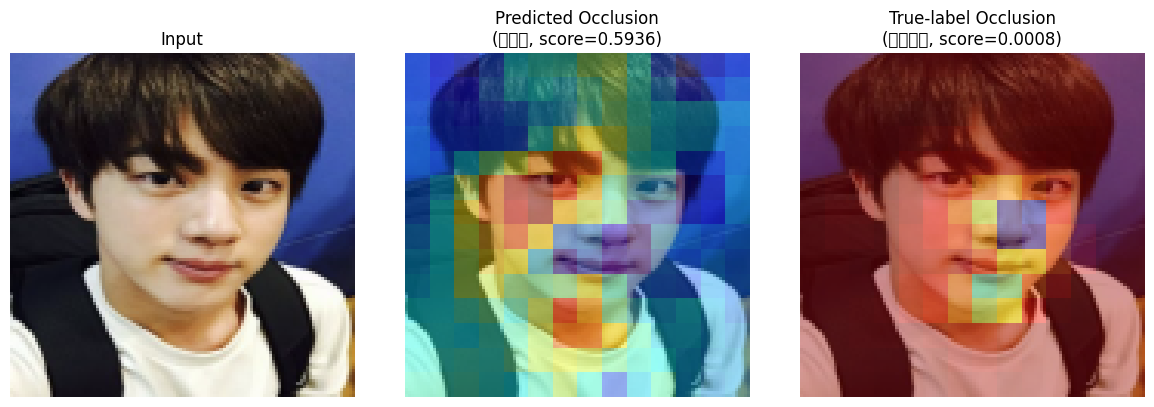

[2] path       : infer\occlusion_check\알파카상\스크린샷 2026-03-09 191143.png
true class     : 알파카상
pred class     : 늑대상
pred score     : 0.2861
true-label score: 0.0060


C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 45713 (\N{HANGUL SYLLABLE NEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45713 (\N{HANGUL SYLLABLE NEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


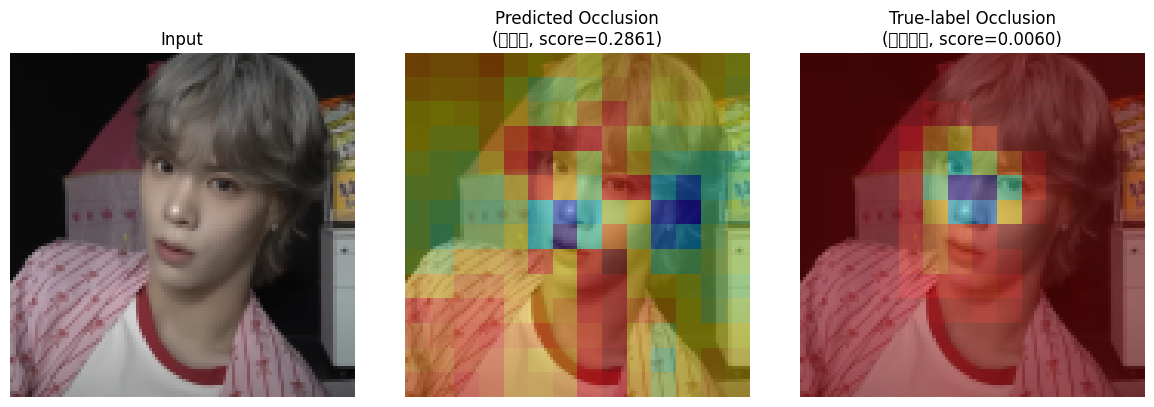

[3] path       : infer\occlusion_check\알파카상\스크린샷 2026-03-09 191202.png
true class     : 알파카상
pred class     : 알파카상
pred score     : 0.5261
true-label score: 0.5261


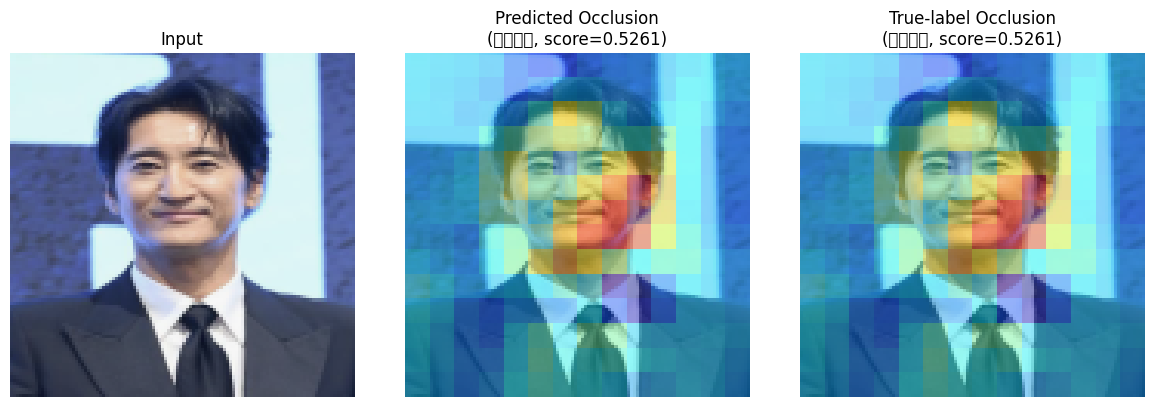

[4] path       : infer\occlusion_check\코알라상\스크린샷 2026-03-09 191309.png
true class     : 코알라상
pred class     : 코알라상
pred score     : 0.7283
true-label score: 0.7283


C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


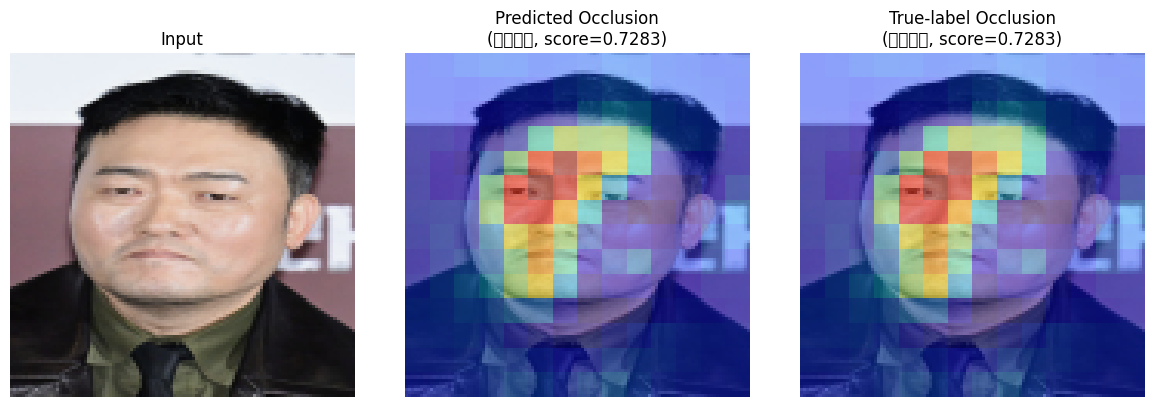

[5] path       : infer\occlusion_check\코알라상\스크린샷 2026-03-09 191314.png
true class     : 코알라상
pred class     : 원숭이상
pred score     : 0.5205
true-label score: 0.0011


C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 49709 (\N{HANGUL SYLLABLE SUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49709 (\N{HANGUL SYLLABLE SUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\workspace\project2\gachikium\.venv\Lib\site-pa

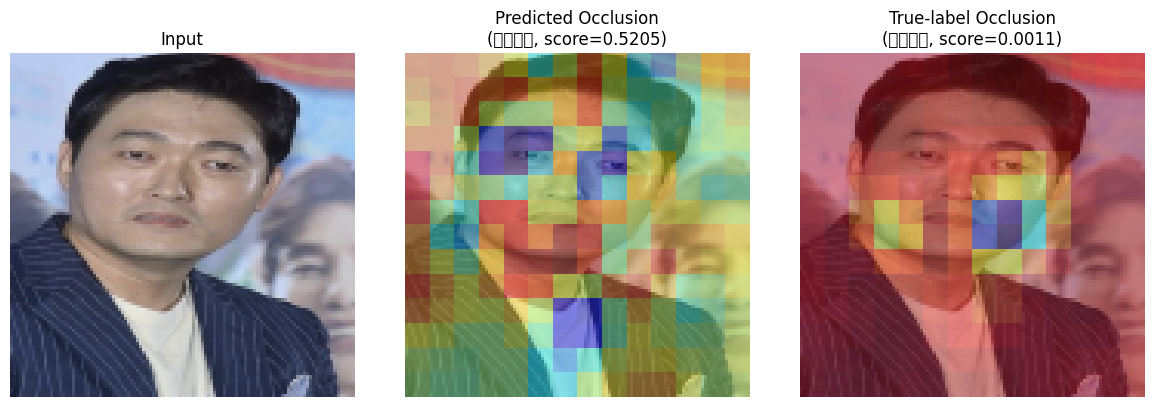

[6] path       : infer\occlusion_check\코알라상\스크린샷 2026-03-10 092521.png
true class     : 코알라상
pred class     : 오리상
pred score     : 0.7449
true-label score: 0.0029


C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


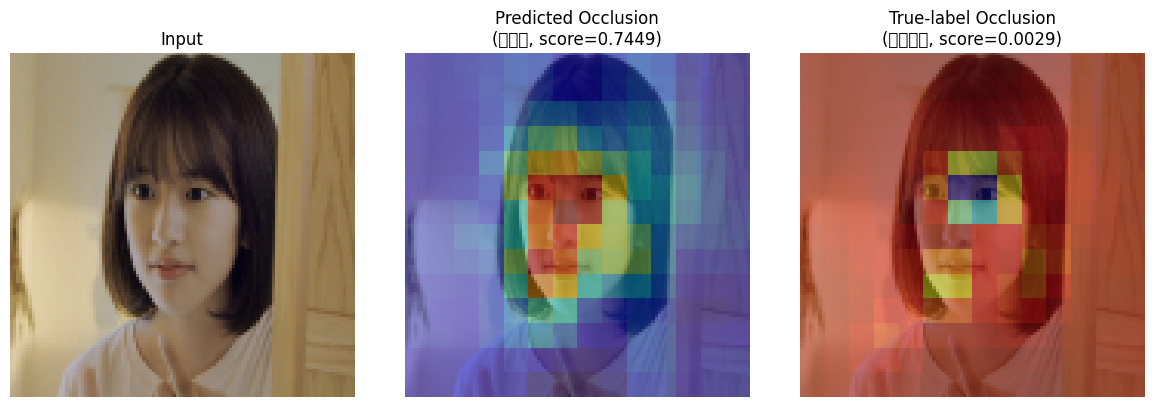

[7] path       : infer\occlusion_check\너구리상\스크린샷 2026-03-09 190940.png
true class     : 너구리상
pred class     : 너구리상
pred score     : 0.9260
true-label score: 0.9260


C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


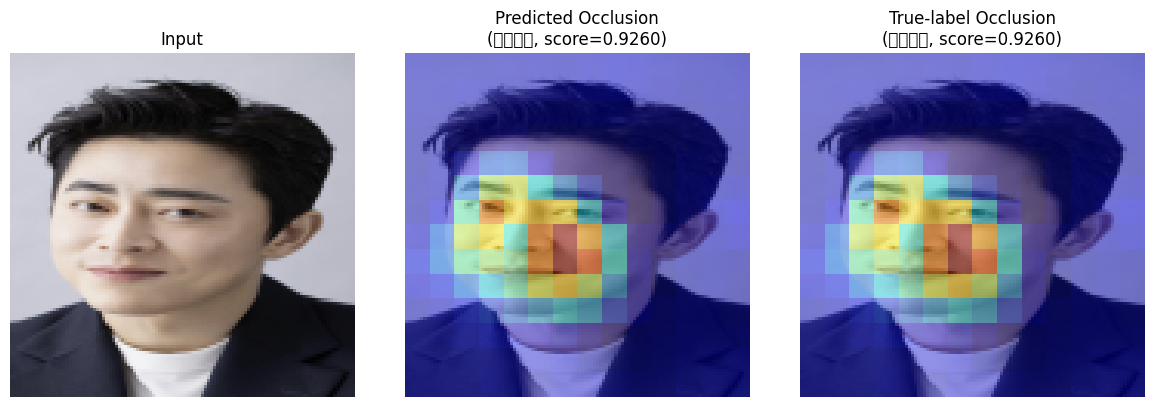

[8] path       : infer\occlusion_check\너구리상\스크린샷 2026-03-09 191013.png
true class     : 너구리상
pred class     : 원숭이상
pred score     : 0.3719
true-label score: 0.0520


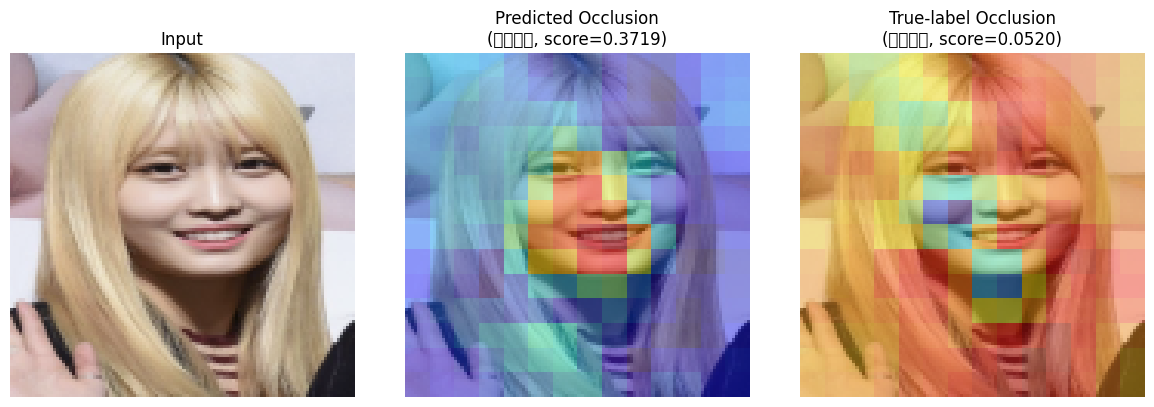

[9] path       : infer\occlusion_check\너구리상\스크린샷 2026-03-09 191045.png
true class     : 너구리상
pred class     : 코알라상
pred score     : 0.2556
true-label score: 0.0440


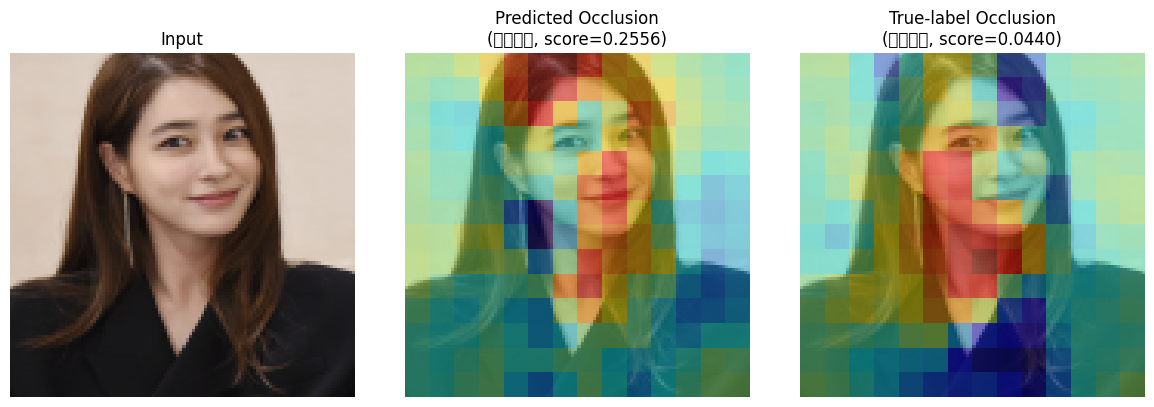

[10] path       : infer\occlusion_check\말상\스크린샷 2026-03-09 190732.png
true class     : 말상
pred class     : 오리상
pred score     : 0.3781
true-label score: 0.0016


C:\Users\user\AppData\Local\Temp\ipykernel_27868\2532838932.py:32: UserWarning: Glyph 47568 (\N{HANGUL SYLLABLE MAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\workspace\project2\gachikium\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47568 (\N{HANGUL SYLLABLE MAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


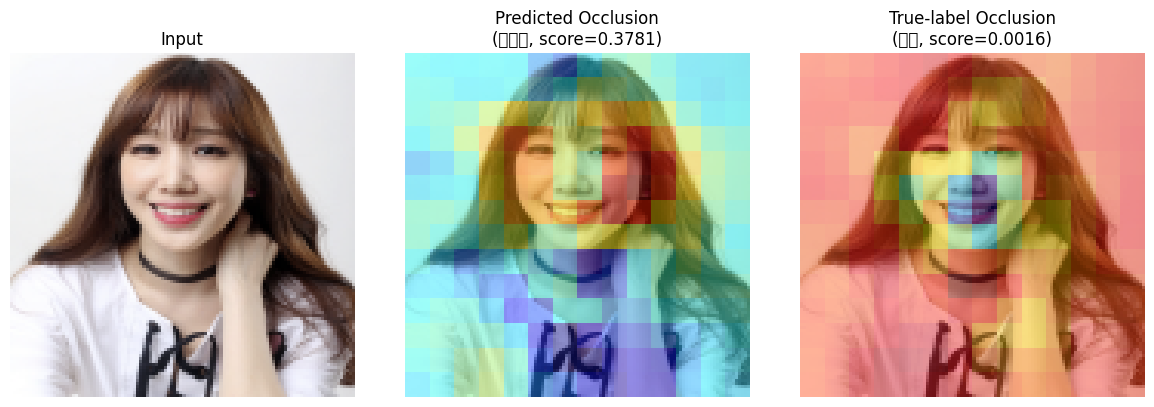

[11] path       : infer\occlusion_check\말상\스크린샷 2026-03-09 190755.png
true class     : 말상
pred class     : 코알라상
pred score     : 0.4528
true-label score: 0.0560


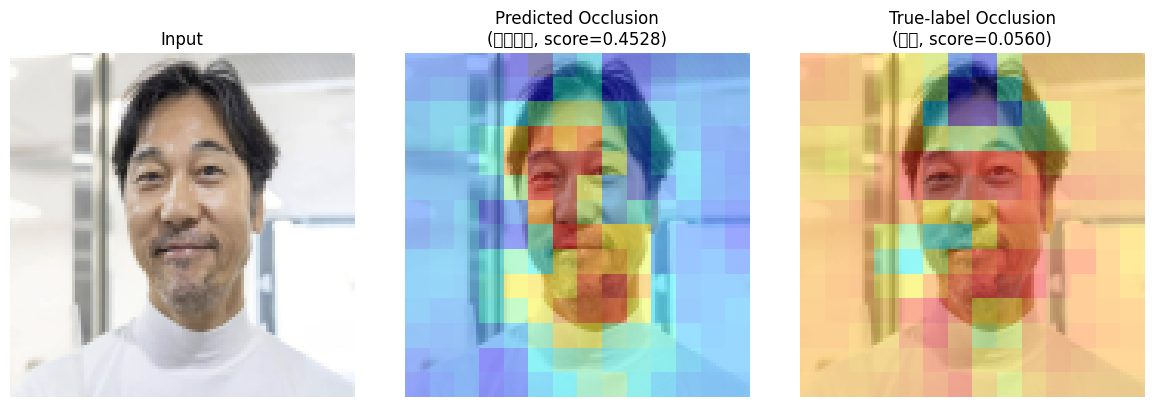

[12] path       : infer\occlusion_check\말상\스크린샷 2026-03-09 190901.png
true class     : 말상
pred class     : 늑대상
pred score     : 0.2674
true-label score: 0.1687


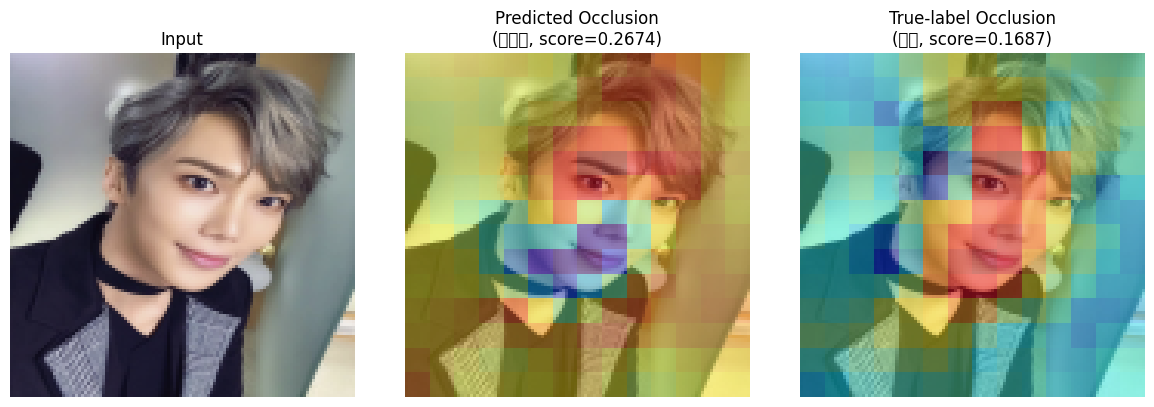

In [13]:
def show_occlusion_results(results, max_show=None):
    valid_results = [r for r in results if r["ok"]]

    if max_show is not None:
        valid_results = valid_results[:max_show]

    for i, r in enumerate(valid_results, start=1):
        print("=" * 100)
        print(f"[{i}] path       : {r['path']}")
        print(f"true class     : {r['true_name']}")
        print(f"pred class     : {r['pred_name']}")
        print(f"pred score     : {r['pred_base_score']:.4f}")
        print(f"true-label score: {r['true_base_score']:.4f}")

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.title("Input")
        plt.axis("off")
        plt.imshow(r["img_rgb"])

        plt.subplot(1, 3, 2)
        plt.title(f"Predicted Occlusion\n({r['pred_name']}, score={r['pred_base_score']:.4f})")
        plt.axis("off")
        plt.imshow(r["pred_overlay"])

        plt.subplot(1, 3, 3)
        plt.title(f"True-label Occlusion\n({r['true_name']}, score={r['true_base_score']:.4f})")
        plt.axis("off")
        plt.imshow(r["true_overlay"])

        plt.tight_layout()
        plt.show()

show_occlusion_results(results)

## 8. 과적합 여부 확인

In [14]:
from sklearn.metrics import accuracy_score

train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Gap:", train_acc - test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.91
Gap: 0.08999999999999997


- Train Accuracy = 1.0
→ 학습 데이터는 전부 맞춤
- Test Accuracy = 0.91
→ 새로운 데이터에서는 91%
- Gap = 0.09
→ 성능 차이가 9%p

## 9. 재학습

### 1) 전처리 + 얼굴 크롭 + 정렬 + 저장

In [16]:
from pathlib import Path
import shutil
import cv2
import numpy as np
from insightface.app import FaceAnalysis

# =========================================================
# 경로 설정
# =========================================================
RAW_DIR = Path("./dataset/new_data")
PROCESSED_DIR = Path("./dataset/new_selected50")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# 얼굴 분석기 로드
# =========================================================
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))   # GPU 없으면 ctx_id=-1

# =========================================================
# 유틸
# =========================================================
def imread_unicode(path: Path):
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    return img

def imwrite_unicode(path: Path, image):
    ext = path.suffix
    result, encoded_img = cv2.imencode(ext, image)
    if result:
        path.parent.mkdir(parents=True, exist_ok=True)
        encoded_img.tofile(str(path))
        return True
    return False

valid_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# =========================================================
# 전처리 실행
# =========================================================
total_raw = 0
total_saved = 0
failed = []

for class_dir in sorted(RAW_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    cls_name = class_dir.name
    save_cls_dir = PROCESSED_DIR / cls_name
    save_cls_dir.mkdir(parents=True, exist_ok=True)

    image_paths = [p for p in class_dir.iterdir() if p.suffix.lower() in valid_exts]
    print(f"\n[CLASS] {cls_name} | 원본 {len(image_paths)}장")

    saved_count = 0

    for idx, img_path in enumerate(image_paths, start=1):
        total_raw += 1

        img = imread_unicode(img_path)
        if img is None:
            failed.append((str(img_path), "이미지 로드 실패"))
            continue

        faces = app.get(img)

        if len(faces) == 0:
            failed.append((str(img_path), "얼굴 미검출"))
            continue

        # 가장 큰 얼굴 선택
        face = max(faces, key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1]))

        # InsightFace normed_embedding 말고, aligned crop용 norm_crop 사용
        try:
            from insightface.utils import face_align
            aligned = face_align.norm_crop(img, landmark=face.kps, image_size=112)
        except Exception as e:
            failed.append((str(img_path), f"정렬 실패: {e}"))
            continue

        out_path = save_cls_dir / f"{cls_name}_{saved_count:03d}.jpg"
        ok = imwrite_unicode(out_path, aligned)
        if ok:
            saved_count += 1
            total_saved += 1
        else:
            failed.append((str(img_path), "저장 실패"))

    print(f"[CLASS] {cls_name} | 저장 {saved_count}장")

print("\n====================")
print("전처리 완료")
print("원본 이미지 수:", total_raw)
print("저장 성공 수:", total_saved)
print("실패 수:", len(failed))

if failed:
    print("\n[실패 목록 일부]")
    for item in failed[:20]:
        print(item)

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\user/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']

c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


[CLASS] 말상 | 저장 23장

[CLASS] 알파카상 | 원본 23장
[CLASS] 알파카상 | 저장 23장

[CLASS] 오리상 | 원본 23장
[CLASS] 오리상 | 저장 23장

[CLASS] 코알라상 | 원본 23장
[CLASS] 코알라상 | 저장 23장

전처리 완료
원본 이미지 수: 92
저장 성공 수: 92
실패 수: 0


### 2) new_selected50 → new_train, new_test 분할

In [17]:
from pathlib import Path
import shutil
import random

PROCESSED_DIR = Path("./dataset/new_selected50")
TRAIN_DIR = Path("./dataset/new_train")
TEST_DIR = Path("./dataset/new_test")

TRAIN_DIR.mkdir(parents=True, exist_ok=True)
TEST_DIR.mkdir(parents=True, exist_ok=True)

random.seed(42)

valid_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# 기존 분할 폴더 비우고 다시 만들고 싶으면 아래 주석 해제
# if TRAIN_DIR.exists():
#     shutil.rmtree(TRAIN_DIR)
# if TEST_DIR.exists():
#     shutil.rmtree(TEST_DIR)
# TRAIN_DIR.mkdir(parents=True, exist_ok=True)
# TEST_DIR.mkdir(parents=True, exist_ok=True)

for class_dir in sorted(PROCESSED_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    cls_name = class_dir.name
    images = [p for p in class_dir.iterdir() if p.suffix.lower() in valid_exts]
    random.shuffle(images)

    n = len(images)

    if n < 10:
        print(f"[WARN] {cls_name}: 전처리 완료 이미지가 너무 적음 ({n}장)")
        continue

    test_count = max(5, int(n * 0.2))
    train_imgs = images[:-test_count]
    test_imgs = images[-test_count:]

    train_cls_dir = TRAIN_DIR / cls_name
    test_cls_dir = TEST_DIR / cls_name
    train_cls_dir.mkdir(parents=True, exist_ok=True)
    test_cls_dir.mkdir(parents=True, exist_ok=True)

    # 기존 파일 제거하고 새로 복사하고 싶으면 아래 주석 해제
    # for p in train_cls_dir.iterdir():
    #     if p.is_file():
    #         p.unlink()
    # for p in test_cls_dir.iterdir():
    #     if p.is_file():
    #         p.unlink()

    for src in train_imgs:
        shutil.copy2(src, train_cls_dir / src.name)

    for src in test_imgs:
        shutil.copy2(src, test_cls_dir / src.name)

    print(f"{cls_name}: train={len(train_imgs)}, test={len(test_imgs)}")

말상: train=18, test=5
알파카상: train=18, test=5
오리상: train=18, test=5
코알라상: train=18, test=5


### 3) ArcFace 임베딩 추출 + 재학습 + 테스트

In [19]:
from pathlib import Path
import shutil
import random
import cv2
import numpy as np
import joblib
import optuna
import pandas as pd

from insightface.app import FaceAnalysis
from insightface.utils import face_align

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =========================================================
# 설정
# =========================================================
USE_GPU = True   # GPU 없으면 False로 변경
RANDOM_SEED = 42
N_TRIALS = 30

RAW_DIR = Path("./dataset/new_data")
PROCESSED_DIR = Path("./dataset/new_selected50")
TRAIN_DIR = Path("./dataset/new_train")
TEST_DIR = Path("./dataset/new_test")
MODEL_DIR = Path("./model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

valid_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# =========================================================
# 유틸 함수
# =========================================================
def imread_unicode(path: Path):
    data = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

def imwrite_unicode(path: Path, image):
    result, encoded_img = cv2.imencode(".jpg", image)
    if result:
        path.parent.mkdir(parents=True, exist_ok=True)
        encoded_img.tofile(str(path))
        return True
    return False

def l2_normalize(x):
    return x / (np.linalg.norm(x) + 1e-12)

def get_embedding_112_bgr(img_bgr_112, rec):
    emb = rec.get_feat(img_bgr_112)
    emb = np.asarray(emb).reshape(-1)
    return l2_normalize(emb).astype(np.float32)


# =========================================================
# 1. 얼굴 분석기 준비
# =========================================================
ctx_id = 0 if USE_GPU else -1

app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=ctx_id, det_size=(640, 640))

rec = None
for m in app.models.values():
    if hasattr(m, "get_feat"):
        rec = m
        break

if rec is None:
    raise RuntimeError("ArcFace recognition model(get_feat)을 찾지 못했습니다.")


# =========================================================
# 2. new_data -> new_selected50
#    얼굴 검출 / 크롭 / 정렬
# =========================================================
def preprocess_and_crop():
    print("\n====================")
    print("[1] 전처리 + 얼굴 크롭 시작")
    print("====================")
    print("현재 작업 폴더:", Path.cwd())
    print("RAW_DIR:", RAW_DIR.resolve())
    print("RAW_DIR 존재 여부:", RAW_DIR.exists())

    if not RAW_DIR.exists():
        raise FileNotFoundError(f"RAW_DIR가 존재하지 않습니다: {RAW_DIR.resolve()}")

    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

    total_raw = 0
    total_saved = 0
    failed = []

    for class_dir in sorted(RAW_DIR.iterdir()):
        if not class_dir.is_dir():
            continue

        cls_name = class_dir.name
        save_cls_dir = PROCESSED_DIR / cls_name
        save_cls_dir.mkdir(parents=True, exist_ok=True)

        # 하위 폴더까지 모두 탐색
        image_paths = [
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in valid_exts
        ]

        print(f"\n[CLASS] {cls_name} | 원본 {len(image_paths)}장")
        saved_count = 0

        for img_path in image_paths:
            total_raw += 1

            img = imread_unicode(img_path)
            if img is None:
                failed.append((str(img_path), "이미지 로드 실패"))
                continue

            faces = app.get(img)
            if len(faces) == 0:
                failed.append((str(img_path), "얼굴 미검출"))
                continue

            # 가장 큰 얼굴 선택
            face = max(
                faces,
                key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1])
            )

            try:
                aligned = face_align.norm_crop(img, landmark=face.kps, image_size=112)
            except Exception as e:
                failed.append((str(img_path), f"정렬 실패: {e}"))
                continue

            out_path = save_cls_dir / f"{cls_name}_{saved_count:03d}.jpg"
            if imwrite_unicode(out_path, aligned):
                saved_count += 1
                total_saved += 1
            else:
                failed.append((str(img_path), "저장 실패"))

        print(f"[CLASS] {cls_name} | 저장 {saved_count}장")

    print("\n====================")
    print("전처리 완료")
    print("원본 이미지 수:", total_raw)
    print("저장 성공 수:", total_saved)
    print("실패 수:", len(failed))

    if failed:
        print("\n[실패 목록 일부]")
        for item in failed[:20]:
            print(item)


# =========================================================
# 3. new_selected50 -> new_train / new_test 분할
# =========================================================
def split_train_test():
    print("\n====================")
    print("[2] train / test 분할 시작")
    print("====================")

    if not PROCESSED_DIR.exists():
        raise FileNotFoundError(f"PROCESSED_DIR가 존재하지 않습니다: {PROCESSED_DIR.resolve()}")

    # 기존 폴더 초기화
    if TRAIN_DIR.exists():
        shutil.rmtree(TRAIN_DIR)
    if TEST_DIR.exists():
        shutil.rmtree(TEST_DIR)

    TRAIN_DIR.mkdir(parents=True, exist_ok=True)
    TEST_DIR.mkdir(parents=True, exist_ok=True)

    for class_dir in sorted(PROCESSED_DIR.iterdir()):
        if not class_dir.is_dir():
            continue

        cls_name = class_dir.name
        images = [p for p in class_dir.iterdir() if p.suffix.lower() in valid_exts]
        random.shuffle(images)

        n = len(images)

        if n < 10:
            print(f"[WARN] {cls_name}: 전처리 완료 이미지가 너무 적음 ({n}장)")
            continue

        test_count = max(5, int(n * 0.2))
        if test_count >= n:
            test_count = max(1, n - 1)

        train_imgs = images[:-test_count]
        test_imgs = images[-test_count:]

        train_cls_dir = TRAIN_DIR / cls_name
        test_cls_dir = TEST_DIR / cls_name
        train_cls_dir.mkdir(parents=True, exist_ok=True)
        test_cls_dir.mkdir(parents=True, exist_ok=True)

        for src in train_imgs:
            shutil.copy2(src, train_cls_dir / src.name)

        for src in test_imgs:
            shutil.copy2(src, test_cls_dir / src.name)

        print(f"{cls_name}: train={len(train_imgs)}, test={len(test_imgs)}")


# =========================================================
# 4. 임베딩 로드
# =========================================================
def load_embeddings(root_dir: Path, rec):
    X, y = [], []

    classes = sorted([d.name for d in root_dir.iterdir() if d.is_dir()])
    class_to_idx = {c: i for i, c in enumerate(classes)}

    for cls in classes:
        cls_dir = root_dir / cls
        image_paths = [p for p in cls_dir.iterdir() if p.suffix.lower() in valid_exts]

        print(f"[LOAD] {cls}: {len(image_paths)}장")

        for img_path in image_paths:
            img = imread_unicode(img_path)
            if img is None:
                print(f"[WARN] 이미지 로드 실패: {img_path}")
                continue

            if img.shape[:2] != (112, 112):
                img = cv2.resize(img, (112, 112), interpolation=cv2.INTER_AREA)

            try:
                emb = get_embedding_112_bgr(img, rec)
                X.append(emb)
                y.append(class_to_idx[cls])
            except Exception as e:
                print(f"[WARN] 임베딩 실패: {img_path} | {e}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    return X, y, classes


# =========================================================
# 5. 학습 + 평가
# =========================================================
def train_and_evaluate():
    print("\n====================")
    print("[3] 임베딩 추출 + 재학습 + 평가 시작")
    print("====================")

    X_train, y_train, classes = load_embeddings(TRAIN_DIR, rec)
    X_test, y_test, classes_test = load_embeddings(TEST_DIR, rec)

    if classes != classes_test:
        raise RuntimeError("train/test 클래스 구성이 다릅니다.")

    print("\n[DATA SHAPE]")
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test :", X_test.shape)
    print("y_test :", y_test.shape)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    def objective(trial):
        model_type = trial.suggest_categorical("model", ["logreg", "linearsvc"])
        C = trial.suggest_float("C", 1e-3, 1e3, log=True)
        use_pca = trial.suggest_categorical("use_pca", [False, True])

        steps = [("scaler", StandardScaler())]

        if use_pca:
            n_splits = cv.get_n_splits()
            min_fold_train_size = int(len(X_train) * (n_splits - 1) / n_splits)

            max_pca = min(
                256,
                X_train.shape[1],
                min_fold_train_size - 1
            )

            if max_pca < 10:
                raise RuntimeError(f"PCA를 적용하기에 학습 데이터가 너무 적습니다. max_pca={max_pca}")

            n_components = trial.suggest_int("pca_n_components", 10, max_pca)
            steps.append(("pca", PCA(n_components=n_components)))

        if model_type == "logreg":
            clf = LogisticRegression(
                C=C,
                max_iter=3000,
                random_state=RANDOM_SEED
            )
        else:
            clf = LinearSVC(
                C=C,
                random_state=RANDOM_SEED,
                dual=False
            )

        steps.append(("clf", clf))
        pipeline = Pipeline(steps)

        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1
        )
        return scores.mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS)

    print("\n[OPTUNA RESULT]")
    print("Best score :", study.best_value)
    print("Best params:", study.best_params)

    best_params = study.best_params
    steps = [("scaler", StandardScaler())]

    if best_params["use_pca"]:
        steps.append(("pca", PCA(n_components=best_params["pca_n_components"])))

    if best_params["model"] == "logreg":
        final_clf = LogisticRegression(
            C=best_params["C"],
            max_iter=3000,
            random_state=RANDOM_SEED
        )
    else:
        final_clf = LinearSVC(
            C=best_params["C"],
            random_state=RANDOM_SEED,
            dual=False
        )

    steps.append(("clf", final_clf))
    final_model = Pipeline(steps)

    final_model.fit(X_train, y_train)

    train_pred = final_model.predict(X_train)
    test_pred = final_model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print("\n[ACCURACY]")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy :", test_acc)
    print("Gap           :", train_acc - test_acc)

    print("\n[Classification Report - Test]")
    print(classification_report(y_test, test_pred, target_names=classes))

    cm = confusion_matrix(y_test, test_pred)
    print("\n[Confusion Matrix]")
    print(cm)

    row_sum = cm.sum(axis=1)
    diag = np.diag(cm)
    wrong = row_sum - diag
    recall = diag / row_sum

    summary_df = pd.DataFrame({
        "class": classes,
        "total": row_sum,
        "correct": diag,
        "wrong": wrong,
        "recall": recall
    }).sort_values(by=["recall", "wrong"], ascending=[True, False])

    print("\n[혼동 많은 클래스 요약]")
    print(summary_df)

    save_path = MODEL_DIR / "animal_face_retrained_v2.joblib"
    joblib.dump(
        {
            "model": final_model,
            "classes": classes,
            "best_params": best_params,
            "train_acc": train_acc,
            "test_acc": test_acc,
            "summary_df": summary_df
        },
        save_path
    )

    print("\n[저장 완료]")
    print(save_path.resolve())


# =========================================================
# main
# =========================================================
if __name__ == "__main__":
    preprocess_and_crop()
    split_train_test()
    train_and_evaluate()

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\user/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']

c:\workspace\project2\gachikium\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


[CLASS] 말상 | 저장 23장

[CLASS] 알파카상 | 원본 23장
[CLASS] 알파카상 | 저장 23장

[CLASS] 오리상 | 원본 23장
[CLASS] 오리상 | 저장 23장

[CLASS] 코알라상 | 원본 23장
[CLASS] 코알라상 | 저장 23장

전처리 완료
원본 이미지 수: 92
저장 성공 수: 92
실패 수: 0

[2] train / test 분할 시작
말상: train=18, test=5
알파카상: train=18, test=5
오리상: train=18, test=5
코알라상: train=18, test=5

[3] 임베딩 추출 + 재학습 + 평가 시작
[LOAD] 말상: 18장
[LOAD] 알파카상: 18장
[LOAD] 오리상: 18장
[LOAD] 코알라상: 18장
[LOAD] 말상: 5장
[LOAD] 알파카상: 5장
[LOAD] 오리상: 5장


[I 2026-03-10 11:26:51,433] A new study created in memory with name: no-name-8e3b5249-78a7-4351-bc25-916020d90e65


[LOAD] 코알라상: 5장

[DATA SHAPE]
X_train: (72, 512)
y_train: (72,)
X_test : (20, 512)
y_test : (20,)


[I 2026-03-10 11:26:56,269] Trial 0 finished with value: 0.9457142857142857 and parameters: {'model': 'logreg', 'C': 0.1558056200119324, 'use_pca': True, 'pca_n_components': 26}. Best is trial 0 with value: 0.9457142857142857.
[I 2026-03-10 11:27:01,104] Trial 1 finished with value: 0.96 and parameters: {'model': 'linearsvc', 'C': 0.1903435002906885, 'use_pca': False}. Best is trial 1 with value: 0.96.
[I 2026-03-10 11:27:06,002] Trial 2 finished with value: 0.96 and parameters: {'model': 'logreg', 'C': 3.4758165115417734, 'use_pca': False}. Best is trial 1 with value: 0.96.
[I 2026-03-10 11:27:10,767] Trial 3 finished with value: 0.96 and parameters: {'model': 'logreg', 'C': 0.00947484826386908, 'use_pca': True, 'pca_n_components': 56}. Best is trial 1 with value: 0.96.
[I 2026-03-10 11:27:14,455] Trial 4 finished with value: 0.96 and parameters: {'model': 'linearsvc', 'C': 0.1945419236844213, 'use_pca': False}. Best is trial 1 with value: 0.96.
[I 2026-03-10 11:27:14,491] Trial 5 fin


[OPTUNA RESULT]
Best score : 0.96
Best params: {'model': 'linearsvc', 'C': 0.1903435002906885, 'use_pca': False}

[ACCURACY]
Train Accuracy: 1.0
Test Accuracy : 0.95
Gap           : 0.050000000000000044

[Classification Report - Test]
              precision    recall  f1-score   support

          말상       1.00      0.80      0.89         5
        알파카상       1.00      1.00      1.00         5
         오리상       0.83      1.00      0.91         5
        코알라상       1.00      1.00      1.00         5

    accuracy                           0.95        20
   macro avg       0.96      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20


[Confusion Matrix]
[[4 0 1 0]
 [0 5 0 0]
 [0 0 5 0]
 [0 0 0 5]]

[혼동 많은 클래스 요약]
  class  total  correct  wrong  recall
0    말상      5        4      1     0.8
1  알파카상      5        5      0     1.0
2   오리상      5        5      0     1.0
3  코알라상      5        5      0     1.0

[저장 완료]
C:\workspace\project2\gachikium\유현희\model\an

- 혼동이 많이 발생한 클래스를 confusion matrix를 통해 추출하고, 해당 클래스의 데이터만 추가 수집하여 다시 학습을 수행
- 추가 수집한 이미지는 얼굴 검출 및 정렬 전처리를 거쳐 학습 데이터로 사용하였으며, ArcFace 임베딩 기반으로 재학습한 결과 테스트 정확도 0.95를 기록함.
- 혼동 클래스 중심의 선택적 데이터 보강이 성능 개선에 효과적임을 확인함.